In [16]:
import pandas as pd
import requests
import matplotlib.pyplot as plt

In [17]:
"""Fetch personal client id, and website url."""
client_id = open('C:/Users/danie/Documents/NMBU 4.år/Inf 201/W41_42/Client_id_frostmet.txt').read().strip()
print(client_id)
endpoint = 'https://frost.met.no/observations/v0.jsonld'

195aadb0-a0cf-4c77-9a8d-2c24e327f3f8


In [18]:
"""Parameters to fetch tempererature data"""

parameters_temp = {
    'sources':'SN17850',
    'elements': 'mean(air_temperature P1D)',
    'referencetime': '2025-01-01/2026-01-01'
}

In [19]:
"""Pameters to fetch precipitation amounts"""

parameters_precipitation ={
    'sources': 'SN17850',
    'elements': 'sum(precipitation_amount P1D)',
    'referencetime':'2025-01-01/2026-01-01'
}

In [20]:
""" Request data access from website"""

temp_response = requests.get(endpoint, parameters_temp, auth=(client_id, ""))
preci_response = requests.get(endpoint, parameters_precipitation, auth=(client_id, ""))
print(temp_response.status_code,',', preci_response.status_code)


200 , 200


In [21]:
""" Convert from json to Python objects"""
temp_payload = temp_response.json()
preci_payload = preci_response.json()


In [22]:
""" Create lists of the data within payload variables that later can be converted to pandas dataframes"""

temp_data = [{'Time': pd.to_datetime(entry['referenceTime']), 
              'Average daily temperature [C]': entry['observations'][0]['value']}
              for entry in temp_payload['data']]

preci_data = [{'Time': pd.to_datetime(entry['referenceTime']),
               'Daily precipitation amount [mm]': entry['observations'][0]['value']}
               for entry in preci_payload['data']]

In [23]:
""" Create two dataframes from prev created data sets, this allows us to make one plot containing both data sets """
temp_df = pd.DataFrame(temp_data)
preci_df = pd.DataFrame(preci_data)


In [24]:
""" Summary of temperature data """

min_temp = temp_df['Average daily temperature [C]'].min()
max_temp = temp_df['Average daily temperature [C]'].max()
mean_temp = temp_df['Average daily temperature [C]'].mean()
median_temp = temp_df['Average daily temperature [C]'].median()

print(f"""Summary table of daily mean temperatures measured on SN17850
    'Mean temperature'          :     {mean_temp:.2f}
    'Median temperature'        :     {median_temp:.2f}
    'Minimum mean daily temp'   :   {min_temp:.2f}
    'Maximum mean daily temp'   :    {max_temp:.2f} """)

Summary table of daily mean temperatures measured on SN17850
    'Mean temperature'          :     7.87
    'Median temperature'        :     8.30
    'Minimum mean daily temp'   :   -15.50
    'Maximum mean daily temp'   :    23.70 


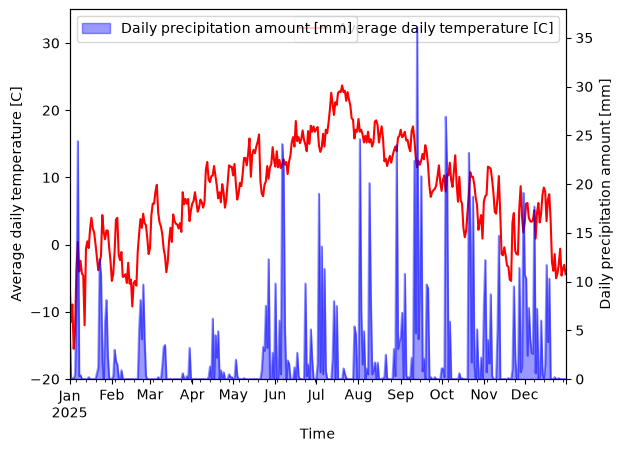

In [25]:
""" creating the plots """
fig, ax1 = plt.subplots()
temp_df.plot(x='Time', y='Average daily temperature [C]', kind='line', color='red',
             ax=ax1, label='Average daily temperature [C]')
ax1.set_ylim(-20,35)
ax1.set_ylabel('Average daily temperature [C]')

ax2 = ax1.twinx()

preci_df.plot(x='Time', y='Daily precipitation amount [mm]', kind='area', color='blue',
             label='Daily precipitation amount [mm]', ax = ax2 , alpha = 0.4)
ax2.set_ylabel('Daily precipitation amount [mm]')

plt.show()         



